In [5]:
import os
import cv2
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib inline

In [6]:
def make_xn_time_video(
    x,
    n,
    t=None,
    name="xn_trajectory",
    frames_dir=None,
    fps=30,
    dpi=200,
    out_size=(1920, 1080),
    linewidth=3.0,
    markersize=10.0,
    pad_frac=0.05,
    show_grid=False
):

        out_mp4 = str(name)
    if not out_mp4.lower().endswith(".mp4"):
        out_mp4 += ".mp4"
    out_mp4 = os.path.abspath(out_mp4)

    x = np.asarray(x, dtype=float).ravel()
    n = np.asarray(n, dtype=float).ravel()
    assert len(x) == len(n), "x and n must have the same length"
    T = len(x)

    if t is None:
        t = np.arange(T, dtype=float)
    else:
        t = np.asarray(t, dtype=float).ravel()
        assert len(t) == T, "t must have the same length as x and n"

    def padded_limits(y):
        y_min = float(np.min(y))
        y_max = float(np.max(y))
        if np.isclose(y_min, y_max):
            y_min -= 1.0
            y_max += 1.0
        rng = y_max - y_min
        return (y_min - pad_frac * rng, y_max + pad_frac * rng)

    x_lim = padded_limits(x)
    n_lim = padded_limits(n)
    t_lim = (float(np.min(t)), float(np.max(t)))

    if frames_dir is not None:
        os.makedirs(frames_dir, exist_ok=True)

    w, h = out_size
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    # Remove old file with same name to avoid confusion
    if os.path.exists(out_mp4):
        os.remove(out_mp4)

    writer = cv2.VideoWriter(out_mp4, fourcc, fps, (w, h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open video writer for: {out_mp4}")

    fig = plt.figure(figsize=(10, 6), dpi=dpi)
    gs = fig.add_gridspec(2, 1, hspace=0.25)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

    for ax in (ax1, ax2):
        ax.set_facecolor("white")
        ax.grid(show_grid, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=12)

    ax1.set_ylabel("x", fontsize=14)
    ax2.set_ylabel("n", fontsize=14)
    ax2.set_xlabel("time", fontsize=14)

    ax1.set_xlim(t_lim)
    ax1.set_ylim(x_lim)
    ax2.set_ylim(n_lim)

    (line_x,) = ax1.plot([], [], "-", color="black", linewidth=linewidth)
    (pt_x,)   = ax1.plot([], [], "o", color="black", markersize=markersize)
    (line_n,) = ax2.plot([], [], "-", color="black", linewidth=linewidth)
    (pt_n,)   = ax2.plot([], [], "o", color="black", markersize=markersize)

    try:
        for i in range(T):
            ti = t[: i + 1]
            xi = x[: i + 1]
            ni = n[: i + 1]

            line_x.set_data(ti, xi)
            pt_x.set_data([t[i]], [x[i]])
            line_n.set_data(ti, ni)
            pt_n.set_data([t[i]], [n[i]])

            fig.canvas.draw()
            img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
            img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))

            img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img_bgr = cv2.resize(img_bgr, (w, h), interpolation=cv2.INTER_AREA)

            if frames_dir is not None:
                frame_path = os.path.join(frames_dir, f"frame_{i:04d}.png")
                cv2.imwrite(frame_path, img_bgr)

            writer.write(img_bgr)
    finally:
        writer.release()
        plt.close(fig)

    print(f"Saved video: {out_mp4}")
    if frames_dir is not None:
        print(f"Saved frames to: {frames_dir}")


### 1. Clearance / elimination of DCCs

In [122]:
def f(k,n):
    return n / (n+k)

def x(x,alphan,betan,dt):
    return (x*(1-x)*(-(alphan+betan)*x+alphan))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

def Mn(f_n,Mh,Ms):
    return (1-f_n)*Mh + f_n*Ms

#### Hostile microenvironment

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha\frac{(n-k)}{n+k} & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \frac{n-k}{n+k}\right) \bigl(\beta x_2 + \alpha(1-x_2) \bigr)
\end{equation}

### $\rho<k$

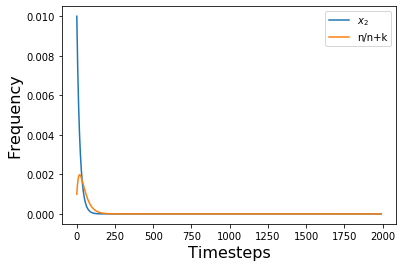

In [123]:
alpha = 0.5
beta = 0.5
eps = 0.16
mu = 0.32
k = 1

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

alphas = []
betas = []

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh, Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
#plt.ylim(-0.05,1.05)
plt.show()

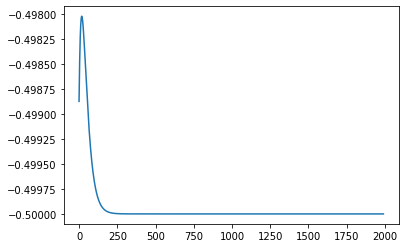

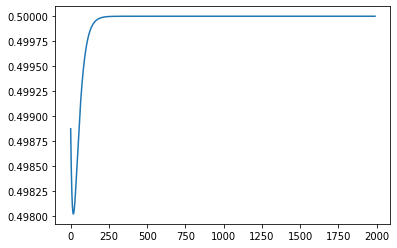

In [127]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [ ]:
print(f"alpha={alpha}, beta={beta}")

In [32]:
print(f"rho={eps/mu}, k={k}")
print(f"rho_hat={eps/(mu*k)} < 1")

rho=0.5, k=1
rho_hat=0.5 < 1


In [14]:
# -------------------------
# Example usage:
# x = np.array([...])  # length T
# n = np.array([...])  # length T
# t = np.linspace(0, 50, len(x))  # optional
t = np.arange(1, 200.0001, dt)
#make_xn_time_video(x, n, t=t, name="elimination_case1")
make_xn_time_video(xs[:-1], f(k,np.array(ns))[:-1], t=t, name="case1", frames_dir="frames", fps=30, out_size=(1920,1080))

Saved video: /Users/guillermo/Code/dynamics_dormancy/case1.mp4
Saved frames to: frames


### 2. Persistence without macroscopic growth (Dormancy)

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way, the dynamics of the cancer cells population is,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \beta\left( \frac{n-k}{n+k}\right) x_2 + \alpha(1-x_2)\right)
\end{equation}

### $\rho<k$

In [132]:
def f(k,n):
    return n / (n+k)

def x(x,alphan,betan,dt):
    return (x*(1-x)*(-(alphan+betan)*x+alphan))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [alpha, 0]])

def Mn(f_n,Mh,Ms):
    return (1-f_n)*Mh + f_n*Ms

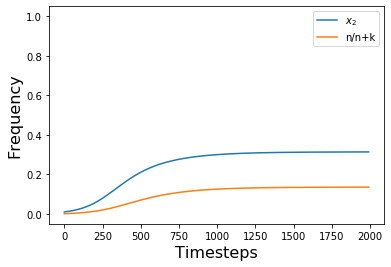

In [130]:
alpha = 0.1
beta = 0.3
eps = 0.04
mu = 0.08
k = 1

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

alphas = []
betas = []

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

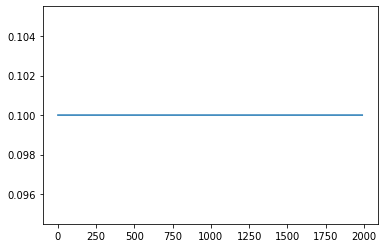

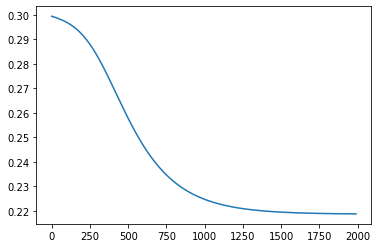

In [131]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [ ]:
print(f"alpha={alpha}, beta={beta}")

In [67]:
print(f"rho={eps/mu} < k={k}")
print(f"rho_hat={eps/(mu*k)} < 1")

rho=0.5 < k=1
rho_hat=0.5 < 1


In [69]:
t = np.arange(1, 200.0001, dt)
make_xn_time_video(xs[:-1], f(k,np.array(ns))[:-1], t=t, name="case2", frames_dir="frames", fps=30, out_size=(1920,1080))

Saved video: /Users/guillermo/Code/dynamics_dormancy/case2.mp4
Saved frames to: frames


### 3. Awakening / metastatic outgrowth

$$M
=
(1-f(n))M_h + f(n)M_s
= 
(1-f(n))\begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
+
f(n)\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
$$

### $\rho>k$

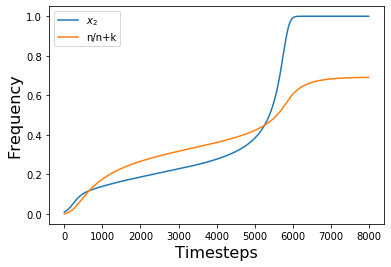

In [133]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]
alphas = []
betas = []

for t in np.arange(1, 800.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

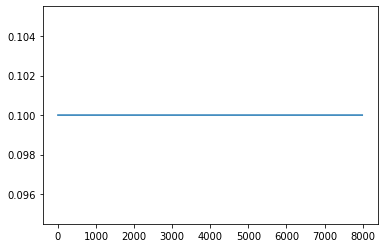

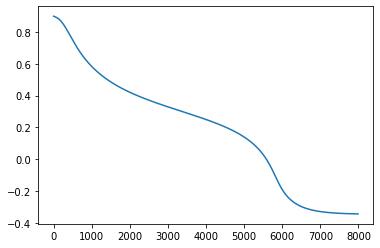

In [134]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [81]:
print(f"alpha={alpha}, beta={beta}")

alpha=0.1, beta=0.9


In [82]:
print(f"rho={eps/mu} > k={k}")
print(f"rho_hat={eps/(mu*k)} > 1")

rho=4.5 > k=2
rho_hat=2.25 > 1


In [84]:
t = np.arange(1, 800.0001, dt)
make_xn_time_video(xs[:-1], f(k,np.array(ns))[:-1], t=t, name="case3", frames_dir="frames", fps=30, out_size=(1920,1080))

Saved video: /Users/guillermo/Code/dynamics_dormancy/case2.mp4
Saved frames to: frames


### 4. Multi-wave seeding / priming-driven relapse (history dependence) --> Vanishes

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha\frac{(n-k)}{n+k} & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \frac{n-k}{n+k}\right) \bigl(\beta x_2 + \alpha(1-x_2) \bigr)
\end{equation}

In [138]:
def switch(k,n):
    return n/(n+k)

def x_2(x2,alphan,betan,dt):
    return (x2*(1-x2)*(-(alphan+betan)*x2+alphan))*dt + x2

def nfunc(n,x2,eps,mu,dt):
    return (eps*x2 - mu*n)*dt + n

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mn(sw,Mh,Ms):
    return (1-sw)*Mh + sw*Ms

### $\rho>k$

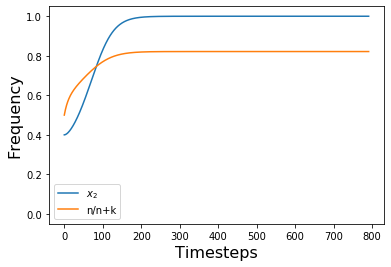

In [139]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.5
k = 0.1

dt = 0.1
x20 = 0.4
n0 = 0.1

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]
alphas = []
betas = []

for t in np.arange(1, 80.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

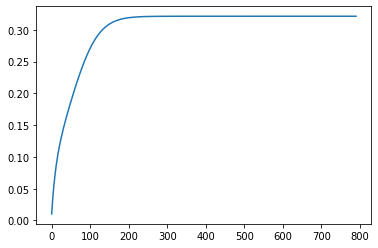

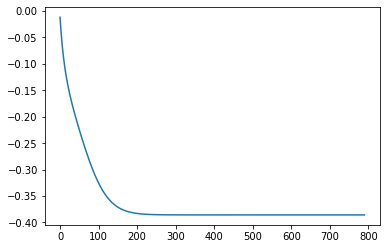

In [140]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [101]:
print(f"alpha={alpha}, beta={beta}")
print(f"rho={eps/mu} > k={k}")
print(f"rho_hat={eps/(mu*k)} > 1")

alpha=0.5, beta=0.6
rho=0.46 > k=0.1
rho_hat=4.6 > 1


In [ ]:
t = np.arange(1, 100.0001, dt)
make_xn_time_video(xs[:-1], f(k,np.array(ns))[:-1], t=t, name="case4", frames_dir="frames", fps=30, out_size=(1920,1080))

### 5. Multi-wave seeding / priming-driven relapse (history dependence) --> Take over

### $\rho>k$

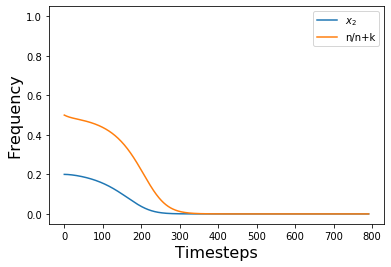

In [141]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.5
k = 0.1

dt = 0.1
x20 = 0.2
n0 = 0.1

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]
alphas = []
betas = []

for t in np.arange(1, 80.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

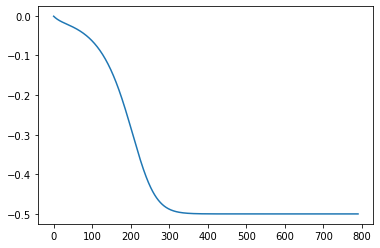

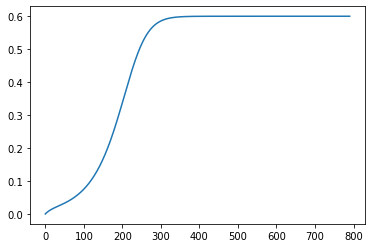

In [142]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [105]:
print(f"alpha={alpha}, beta={beta}")
print(f"rho={eps/mu} > k={k}")
print(f"rho_hat={eps/(mu*k)} > 1")

alpha=0.5, beta=0.6
rho=0.46 > k=0.1
rho_hat=4.6 > 1


In [ ]:
make_xn_time_video(xs[:-1], f(k,np.array(ns))[:-1], t=t, name="case5", frames_dir="frames", fps=30, out_size=(1920,1080))